# Bending playground

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, Angle, AltAz, ICRS, EarthLocation
from astropy.coordinates import BaseCoordinateFrame, BaseRepresentation, CartesianRepresentation, SphericalRepresentation, UnitSphericalRepresentation

from astropy.coordinates import RepresentationMapping
import astropy.coordinates.representation as r
from astropy.coordinates import TimeAttribute, QuantityAttribute, EarthLocationAttribute
from erfa import ufunc as erfa_ufunc
from astropy.utils import classproperty
from astropy.coordinates.matrix_utilities import rotation_matrix
from astropy.coordinates.baseframe import frame_transform_graph

from astropy.coordinates.transformations import FunctionTransform, StaticMatrixTransform

from astropy.modeling.rotations import SphericalRotationSequence

from scipy.interpolate import CloughTocher2DInterpolator, RBFInterpolator, SmoothBivariateSpline
import scipy
scipy.__version__

import dill as pickle

from datetime import datetime
from datetime import timezone

In [2]:
df = pd.read_csv("merged.csv")

az_deg = df["Az"].values
el_deg = df["El"].values

az = np.deg2rad(az_deg)
el = np.deg2rad(el_deg)

offset_az = df["Offset Az"].values
offset_el = df["Offset El"].values

N = len(df)


# ==========================================================
# Build interleaved design matrix
# ==========================================================

X = np.zeros((2*N, 8))

for i in range(N):

    X[2*i] = [
        (1) / np.sin(el[i]), #coef 0
        (np.cos(el[i])) / np.sin(el[i]), #coef 1
        (-np.sin(el[i]) * np.sin(az[i])) / np.sin(el[i]), #coef 2
        (np.sin(el[i]) * np.cos(az[i])) / np.sin(el[i]), #coef 3
        #(np.cos(el[i])**2) / np.sin(el[i]), #coef 4
        #(np.sin(el[i])**2 * np.cos(2 * az[i])) / np.sin(el[i]), #coef 5
        #(np.sin(el[i]) * np.cos(el[i]) * np.cos(az[i])) / np.sin(el[i]), #coef 6
        #(-np.sin(el[i]) * np.cos(el[i]) * np.sin(az[i])) / np.sin(el[i]), #coef 7
        #(-np.sin(el[i])**2 * np.sin(2* az[i])) / np.sin(el[i]), #coef 8
        0,
        0,
        0,
        0,
        #0,
        #0,
        #0,
        #0,
        #0
    ]

    X[2*i+1] = [
        0,
        0,
        0,
        0,
        #0,
        #0,
        #0,
        #0,
        #0,
        1, #coef 9
        np.cos(el[i]),  #coef 10
        -np.sin(el[i]) * np.sin(az[i]), #coef 11
        np.sin(el[i]) * np.cos(az[i]), #coef 12
        #np.cos(el[i])**2, #coef 13
        #np.sin(el[i])**2 * np.cos(2 * az[i]), #coef 14
        #np.sin(el[i]) * np.cos(el[i]) * np.cos(az[i]), #coef 15
        #-np.sin(el[i]) * np.cos(el[i]) * np.sin(az[i]), #coef 16
        #-np.sin(el[i])**2 * np.sin(2* az[i]) #coef 17 (18 total)
    ]


print("Design Matrix Shape:", X.shape)
print(X)


# ==========================================================
# Build matching target vector
# ==========================================================

y = np.zeros(2*N)

for i in range(N):
    y[2*i] = offset_az[i]
    y[2*i+1] = offset_el[i]

print(y)


# ==========================================================
# Solve least squares
# ==========================================================

coef, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print("\nCoefficients:")
print(coef)

# ==========================================================
# Prediction functions
# ==========================================================

def azfit_trig(az_deg, el_deg=None, grid=False):

    az = np.deg2rad(np.asarray(az_deg))

    return (
        coef[0] / np.sin(el[i])
        + coef[1] * ((np.cos(el[i])) / np.sin(el[i]))
        + coef[2] * ((-np.sin(el[i]) * np.sin(az[i])) / np.sin(el[i]))
        + coef[3] * ((np.sin(el[i]) * np.cos(az[i])) / np.sin(el[i]))
        #+ coef[4] * ((np.cos(el[i])**2) / np.sin(el[i]))
        #+ coef[5] * ((np.sin(el[i])**2 * np.cos(2 * az[i])) / np.sin(el[i]))
        #+ coef[6] * ((np.sin(el[i]) * np.cos(el[i]) * np.cos(az[i])) / np.sin(el[i]))
        #+ coef[7] * ((-np.sin(el[i]) * np.cos(el[i]) * np.sin(az[i])) / np.sin(el[i]))
        #+ coef[8] * ((-np.sin(el[i])**2 * np.sin(2* az[i])) / np.sin(el[i]))
    )


def altfit_trig(az_deg=None, el_deg=None, grid=False):

    el = np.deg2rad(np.asarray(el_deg))

    return (
        + coef[4]
        + coef[5] * (np.cos(el[i]))
        + coef[6] * (-np.sin(el[i]) * np.sin(az[i]))
        + coef[7] * (np.sin(el[i]) * np.cos(az[i]))
        #+ coef[8] * (np.cos(el[i])**2)
        #+ coef[14] * (np.sin(el[i])**2 * np.cos(2 * az[i]))
        #+ coef[15] * (np.sin(el[i]) * np.cos(el[i]) * np.cos(az[i]))
        #+ coef[16] * (-np.sin(el[i]) * np.cos(el[i]) * np.sin(az[i]))
        #+ coef[17] * (-np.sin(el[i])**2 * np.sin(2* az[i]))
    )

Design Matrix Shape: (206, 8)
[[ 1.08799294  0.42863579 -0.91448216 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.39396928 -0.84052215
   0.37190151]
 [ 1.08429018  0.41914818 -0.91326339 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.70249343  0.19091483
   0.68560522]
 [ 1.49381656  1.10972425  0.26290325 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.74287853  0.17599434
   0.6458773 ]]
[ 0.067 -0.191  0.068 -0.192  0.066 -0.19   0.069 -0.189  0.071 -0.186
  0.073 -0.184  0.073 -0.183  0.072 -0.183  0.077 -0.179  0.075 -0.186
  0.075 -0.189  0.072 -0.193  0.07  -0.201  0.056 -0.221  0.042 -0.23
  0.023 -0.234  0.004 -0.24  -0.019 -0.248 -0.035 -0.251 -0.044 -0.246
 -0.059 -0.245 -0.067 -0.247 -0.073 -0.248 -0.077 -0.246 -0.079 -0.248
 -0.083 -0.248 -0.084 -0.249 -0.087 -0.25  -0.088 -0.25  -0.09  -0.254
 -0.091 -0.253 -0.092 -0.257 -0.094 -0.259 -0.096 -0.263 -0.097 -0.268
 -0.1 

In [3]:
class bending_model:
    def __init__(self, altfit_func, azfit_func, model_name, model_description):
        self.alt_func = altfit_func
        self.az_func = azfit_func
        self.name = model_name
        self.description = model_description

    def astro_to_drive(self, astro_alt, astro_az):
        deg_alt = Angle(astro_alt*u.deg).wrap_at(180*u.deg).deg
        deg_az = Angle(astro_az*u.deg).wrap_at(360*u.deg).deg
        drive_alt = (astro_alt-self.alt_func(deg_az, deg_alt, grid=False))
        drive_az = (astro_az-self.az_func(deg_az, deg_alt, grid=False))
        return (drive_alt, drive_az)

    def drive_to_astro(self, drive_alt, drive_az):
        deg_alt = Angle(drive_alt*u.deg).wrap_at(180*u.deg).deg
        deg_az = Angle(drive_az*u.deg).wrap_at(360*u.deg).deg
        astro_alt = (drive_alt+self.alt_func(deg_az, deg_alt, grid=False))
        astro_az = (drive_az+self.az_func(deg_az, deg_alt, grid=False))
        return (astro_alt, astro_az)

    def delta(self, alt, az):
        deg_alt = Angle(alt*u.deg).wrap_at(180*u.deg).deg
        deg_az = Angle(az*u.deg).wrap_at(360*u.deg).deg
        delta_alt = self.alt_func(deg_az, deg_alt, grid=False)
        delta_az = self.az_func(deg_az, deg_alt, grid=False)
        return (delta_alt, delta_az)

In [4]:
b = bending_model(
    altfit_func=altfit_trig,
    azfit_func=azfit_trig,
    model_name='testModel',
    model_description='blank'
)

"""
b = bending_model(altfit_func=altfit_spline,
                  azfit_func=azfit_spline,
                  model_name='test_model_v0',
                  model_description=f'generated on {datetime.now().strftime("%Y/%m/%d %H:%M:%S")} using toy data and scipy {scipy.__version__} SmoothBivariateSpline'
                 )
"""

'\nb = bending_model(altfit_func=altfit_spline,\n                  azfit_func=azfit_spline,\n                  model_name=\'test_model_v0\',\n                  model_description=f\'generated on {datetime.now().strftime("%Y/%m/%d %H:%M:%S")} using toy data and scipy {scipy.__version__} SmoothBivariateSpline\'\n                 )\n'

In [5]:
##Chi squared test

#pred_alt = altfit_trig(df["El"].values)
#pred_az  = azfit_trig(df["Az"].values)
az = np.deg2rad(df["Az"].values)
el = np.deg2rad(df["El"].values)

az_pred = (
coef[0] / np.sin(el)
+ coef[1] * ((np.cos(el)) / np.sin(el))
+ coef[2] * ((-np.sin(el) * np.sin(az)) / np.sin(el))
+ coef[3] * ((np.sin(el) * np.cos(az)) / np.sin(el))
)


el_pred = (
coef[4]
+ coef[5] * np.cos(el)
+ coef[6] * (-np.sin(el) * np.sin(az))
+ coef[7] * (np.sin(el) * np.cos(az))
#+ coef[8] * (np.cos(el)**2)
)

df["Model Offset El"] = el_pred
print(el_pred)
df["Model Offset Az"] = az_pred
print(az_pred)


df["El Residual"] = df["Offset El"] - df["Model Offset El"]
df["Az Residual"] = df["Offset Az"] - df["Model Offset Az"]

chi2_el = np.sum(df["El Residual"]**2)
chi2_az = np.sum(df["Az Residual"]**2)
chi2_total = chi2_el + chi2_az

##sigma here is calculated to be variance of the residuals; later, consider variance in...
##fitted parameters
##predictions

"""
N = len(df)
p = 3  #parameters per axis
sigma_el = np.sqrt(np.sum(df["El Residual"]**2) / (N - p))
sigma_az = np.sqrt(np.sum(df["Az Residual"]**2) / (N - p))
print("Estimated sigma El:", sigma_el)
print("Estimated sigma Az:", sigma_az)
"""

print("El RMS:", np.sqrt(np.mean(df["El Residual"]**2)))
print("Az RMS:", np.sqrt(np.mean(df["Az Residual"]**2)))
print("|d| RMS:", np.sqrt(np.mean(df["Az Residual"]**2)+ df["El Residual"]**2))

print("\nIndividual Residuals:")
for index, row in df.iterrows():
    print(f"  El Residual: {row['El Residual']:.6f}, Az Residual: {row['Az Residual']:.6f}")

[-0.18173237 -0.18082886 -0.18022803 -0.17836235 -0.17568979 -0.17408597
 -0.17223493 -0.17177839 -0.17160847 -0.17383353 -0.17820245 -0.18512726
 -0.19644552 -0.21537025 -0.22857028 -0.23794341 -0.24758319 -0.251775
 -0.2525988  -0.25240447 -0.25173818 -0.25143235 -0.25143562 -0.25167582
 -0.25213811 -0.25286942 -0.25473476 -0.25595093 -0.25731564 -0.25966931
 -0.26168045 -0.2633626  -0.26525027 -0.26723181 -0.269818   -0.27289005
 -0.27476539 -0.2776039  -0.27937659 -0.28143662 -0.28293764 -0.28476129
 -0.28631867 -0.28776249 -0.28905217 -0.29024034 -0.28328793 -0.13280063
 -0.21104456 -0.21021808 -0.26917258 -0.26966633 -0.16705306 -0.16797283
 -0.30476952 -0.30483009 -0.21944037 -0.30398664 -0.08095041 -0.24416575
 -0.24310436 -0.23492509 -0.2374836  -0.2402008  -0.28297818 -0.25999372
 -0.16865201 -0.15636109 -0.25416289 -0.29181379 -0.22610776 -0.22444686
 -0.22242764 -0.22079039 -0.21887341 -0.21683502 -0.21515126 -0.11521559
 -0.12514347 -0.13443521 -0.14294255 -0.28141911 -0.2

In [6]:
"""
##10 parameter model
pred_alt = altfit_trig(df["Az"].values, df["El"].values)
pred_az  = azfit_trig(df["Az"].values, df["El"].values)

df["Model Offset El"] = pred_alt
df["Model Offset Az"] = pred_az

df["El Residual"] = df["Offset El"] - df["Model Offset El"]
df["Az Residual"]  = df["Offset Az"] - df["Model Offset Az"]

print("El RMS:", np.sqrt(np.mean(df["El Residual"]**2)))
print("Az RMS:", np.sqrt(np.mean(df["Az Residual"]**2)))

az_test = 292.689301  # degrees
el_test = 61.201706    # degrees

d_el = altfit_trig(az_test, el_test)
d_az = azfit_trig(az_test, el_test)

print("Predicted offsets:")
print("ΔAz:", d_az)
print("ΔEl:", d_el)
"""
az = np.deg2rad(df["Az"].values)
el = np.deg2rad(df["El"].values)

# Predictions
az_pred = (
coef[0] / np.sin(el)
+ coef[1] * ((np.cos(el)) / np.sin(el))
+ coef[2] * ((-np.sin(el) * np.sin(az)) / np.sin(el))
+ coef[3] * ((np.sin(el) * np.cos(az)) / np.sin(el))
)


el_pred = (
coef[4]
+ coef[5] * np.cos(el)
+ coef[6] * (-np.sin(el) * np.sin(az))
+ coef[7] * (np.sin(el) * np.cos(az))
#+ coef[8] * (np.cos(el)**2)
)


for az_p, el_p in zip(az_pred, el_pred):
    print(f"PrEl Offset: {el_p:.6f}  PrAz Offset: {az_p:.6f}")

"""
##6 parameter model
az = np.deg2rad(df["Az"].values)
el = np.deg2rad(df["El"].values)

# Predictions using 3-term formulas
az_pred = coef[0] + coef[1]*np.cos(az) + coef[2]*np.sin(az)
el_pred = coef[3] + coef[4]*np.cos(el) + coef[5]*np.sin(el)

for i in range(len(df)):
    print("PrEl Offset:", el_pred[i], "PrAz Offset:", az_pred[i])
"""

"""
pred_alt = altfit_trig(df["El"].values)
pred_az  = azfit_trig(df["Az"].values)

df["Model Offset El"] = pred_alt
df["Model Offset Az"] = pred_az

df["El Residual"] = df["Offset El"] - df["Model Offset El"]
df["Az Residual"] = df["Offset Az"] - df["Model Offset Az"]

print("El RMS:", np.sqrt(np.mean(df["El Residual"]**2)))
print("Az RMS:", np.sqrt(np.mean(df["Az Residual"]**2)))

az_test = 65.960297 # degrees
el_test = 67.259094   # degrees

d_el = altfit_trig(el_test)
d_az = azfit_trig(az_test)

print("Predicted offsets:")
print("ΔAz:", d_az)
print("ΔEl:", d_el)
"""



PrEl Offset: -0.181732  PrAz Offset: 0.064366
PrEl Offset: -0.180829  PrAz Offset: 0.064642
PrEl Offset: -0.180228  PrAz Offset: 0.064827
PrEl Offset: -0.178362  PrAz Offset: 0.065415
PrEl Offset: -0.175690  PrAz Offset: 0.066311
PrEl Offset: -0.174086  PrAz Offset: 0.066904
PrEl Offset: -0.172235  PrAz Offset: 0.067736
PrEl Offset: -0.171778  PrAz Offset: 0.068033
PrEl Offset: -0.171608  PrAz Offset: 0.068375
PrEl Offset: -0.173834  PrAz Offset: 0.068349
PrEl Offset: -0.178202  PrAz Offset: 0.067298
PrEl Offset: -0.185127  PrAz Offset: 0.064851
PrEl Offset: -0.196446  PrAz Offset: 0.059358
PrEl Offset: -0.215370  PrAz Offset: 0.045885
PrEl Offset: -0.228570  PrAz Offset: 0.032092
PrEl Offset: -0.237943  PrAz Offset: 0.018452
PrEl Offset: -0.247583  PrAz Offset: -0.003550
PrEl Offset: -0.251775  PrAz Offset: -0.023614
PrEl Offset: -0.252599  PrAz Offset: -0.039456
PrEl Offset: -0.252404  PrAz Offset: -0.046837
PrEl Offset: -0.251738  PrAz Offset: -0.058057
PrEl Offset: -0.251432  PrAz 

'\npred_alt = altfit_trig(df["El"].values)\npred_az  = azfit_trig(df["Az"].values)\n\ndf["Model Offset El"] = pred_alt\ndf["Model Offset Az"] = pred_az\n\ndf["El Residual"] = df["Offset El"] - df["Model Offset El"]\ndf["Az Residual"] = df["Offset Az"] - df["Model Offset Az"]\n\nprint("El RMS:", np.sqrt(np.mean(df["El Residual"]**2)))\nprint("Az RMS:", np.sqrt(np.mean(df["Az Residual"]**2)))\n\naz_test = 65.960297 # degrees\nel_test = 67.259094   # degrees\n\nd_el = altfit_trig(el_test)\nd_az = azfit_trig(az_test)\n\nprint("Predicted offsets:")\nprint("ΔAz:", d_az)\nprint("ΔEl:", d_el)\n'

In [ ]:
#For CalculatedOffsets
df = pd.read_csv('TrainedData.csv')
plt.scatter(df['May Az'], df['May El'], color='blue', marker='o', s=5, label= 'May')
#plt.scatter(df['May Calc Az'], df['May Calc El'], color='red', marker='o', s=5, label= 'May Calc')
plt.scatter(df['June Az'], df['June El'], color='green', marker='o', s=5, label= 'June')
#plt.scatter(df['June Calc Az'], df['June Calc El'], color='orange', marker='o', s=5, label= 'June Calc')
plt.xlabel('Azimuth (degree)')
plt.ylabel('Elevation (degree)')
plt.title("Actual Offsets - 8x Scale")
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.legend()


Scale = 8
plt.quiver(
    df['May Az'],
    df['May El'],
    (df['May Calc Az'] - df['May Az']) * Scale,
    (df['May Calc El'] - df['May El']) * Scale,
    color='black',
    width=0.003,
    angles='xy',
    scale_units='xy',
    scale=.75
)

plt.quiver(
    df['June Az'],
    df['June El'],
    (df['June Calc Az'] - df['June Az']) * Scale,
    (df['June Calc El'] - df['June El']) * Scale,
    color='black',
    width=0.003,
    angles='xy',
    scale_units='xy',
    scale=.75
)

plt.savefig('CalcOffsets.png')
plt.close()

In [ ]:
#For Predicted Offsets
plt.scatter(df['May Az'], df['May El'], color='blue', marker='o', s=5, label= 'May')
#plt.scatter(df['May PrAz'], df['May PrEl'], color='red', marker='o', s=5, label= 'May Bending')
#plt.scatter(df['May Calc Az'], df['May Calc El'], color='red', marker='o', s=5, label= 'May Calc')
plt.scatter(df['June Az'], df['June El'], color='green', marker='o', s=5, label= 'June')
#plt.scatter(df['June PrAz'], df['June PrEl'], color='orange', marker='o', s=5, label= 'June Bending')
#plt.scatter(df['June Calc Az'], df['June Calc El'], color='orange', marker='o', s=5, label= 'June Calc')
plt.xlabel('Azimuth (degree)')
plt.ylabel('Elevation (degree)')
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.title("Predicted Offsets - 8x Scale")
plt.legend()

Scale = 8
plt.quiver(
    df['May Az'],
    df['May El'],
    (df['May PrAz'] - df['May Az']) * Scale,
    (df['May PrEl'] - df['May El']) * Scale,
    color='black',
    width=0.003,
    angles='xy',
    scale_units='xy',
    scale=.75
)

plt.quiver(
    df['June Az'],
    df['June El'],
    (df['June PrAz'] - df['June Az']) * Scale,
    (df['June PrEl'] - df['June El']) * Scale,
    color='black',
    width=0.003,
    angles='xy',
    scale_units='xy',
    scale=.75
)


plt.savefig('Predicted Offsets.png')
plt.close()

In [8]:
#Defines grid of constant points, function of each term to plot, a plotting function, and matrix of coefficients

"""
(1) / np.sin(el[i]), #coef 0
        (np.cos(el[i])) / np.sin(el[i]), #coef 1
        (-np.sin(el[i]) * np.sin(az[i])) / np.sin(el[i]), #coef 2
        (np.sin(el[i]) * np.cos(az[i])) / np.sin(el[i]), #coef 3
"""


az = np.arange(0, 360, 20)
el = np.arange(0, 90, 10)

AZ, EL = np.meshgrid(az, el)

# Convert to radians
AZr = np.deg2rad(AZ)
ELr = np.deg2rad(EL)

fa0 = (1) / np.sin(ELr)
fa1 = (np.cos(ELr)) / np.sin(ELr)
fa2= (-np.sin(ELr) * np.sin(AZr) / np.sin(ELr))
fa3= (np.sin(ELr) * np.cos(AZr)) / np.sin(ELr)

fb0 = (1)
fb1 = (np.cos(ELr))
fb2= (-np.sin(ELr) * np.sin(AZr))
fb3= (np.sin(ELr) * np.cos(AZr))


def plot_term(AZ, EL, dAz, dEl, title):
    plt.scatter(AZ, EL, color='blue', marker='o', s=15)
    #plt.quiver(AZ+dAz, EL+dEl, -dAz, -dEl)
    plt.quiver(AZ, EL, dAz, dEl)
    plt.xlabel("Az (deg)")
    plt.ylabel("El (deg)")
    plt.title(title)
    plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
    plt.legend()
    plt.show()

#structured like:
#a0*1 + a1*sin(az) + a2*cos(az)
#b0*1 + b1*sin(el) + b2*cos(el)

a = [coef[0], coef[1], coef[2], coef[3]]   # azimuth coefficients
b = [coef[4], coef[5], coef[6], coef[7]]   # elevation coefficients



/tmp/ipykernel_4424/1639776306.py:22: RuntimeWarning: divide by zero encountered in divide
  fa0 = (1) / np.sin(ELr)
/tmp/ipykernel_4424/1639776306.py:23: RuntimeWarning: divide by zero encountered in divide
  fa1 = (np.cos(ELr)) / np.sin(ELr)
/tmp/ipykernel_4424/1639776306.py:24: RuntimeWarning: invalid value encountered in divide
  fa2= (-np.sin(ELr) * np.sin(AZr) / np.sin(ELr))
/tmp/ipykernel_4424/1639776306.py:25: RuntimeWarning: invalid value encountered in divide
  fa3= (np.sin(ELr) * np.cos(AZr)) / np.sin(ELr)


Plotting individual components, together (Spherical)

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


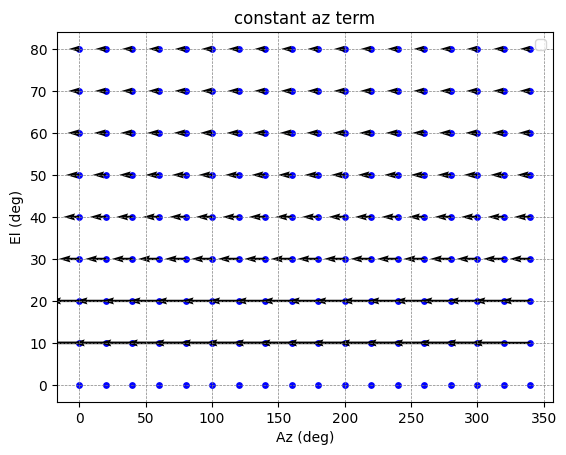

In [9]:
#plot constant of az term
plot_term(AZ, EL,
          a[0]*fa0,
          b[0]*0,
          "constant az term")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


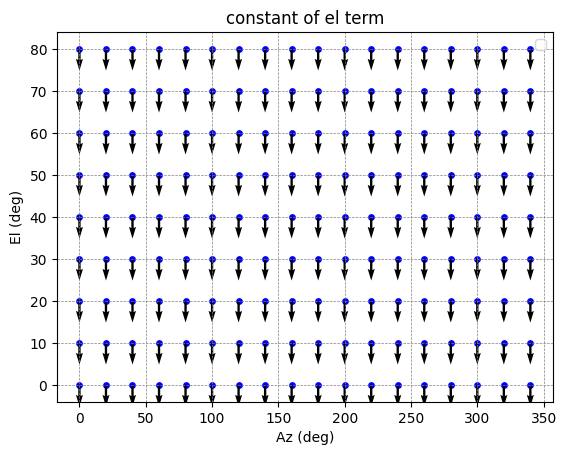

In [10]:
#plot constant of el term
plot_term(AZ, EL,
          a[0]*0,
          b[0]*fb0,
          "constant of el term")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


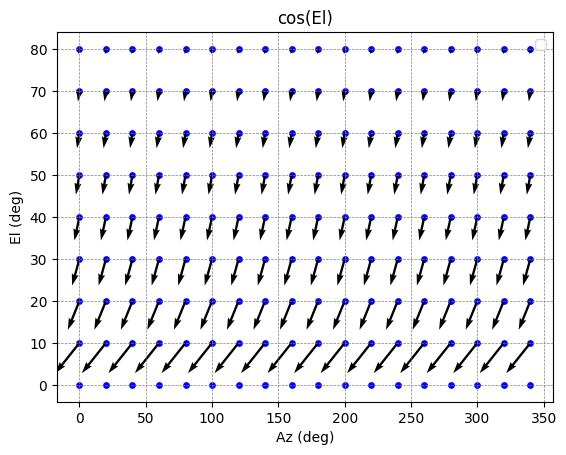

In [11]:
#plot sine term
plot_term(AZ, EL,
          a[1]*fa1,
          b[1]*fb1,
          "cos(El)")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


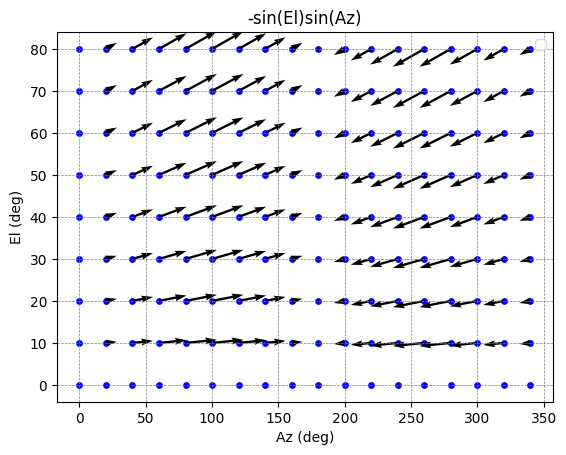

In [13]:
#plot cosine term
plot_term(AZ, EL,
          a[2]*fa2,
          b[2]*fb2,
          "-sin(El)sin(Az)")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


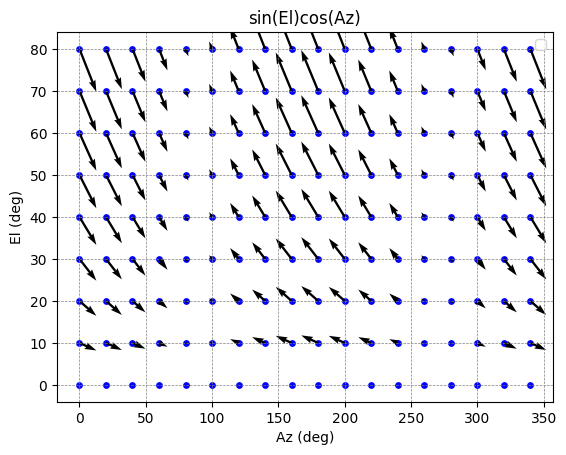

In [14]:
plot_term(AZ, EL,
          a[3]*fa3,
          b[3]*fb3,
          "sin(El)cos(Az)")

Plotting individual components, seperately (Spherical)

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


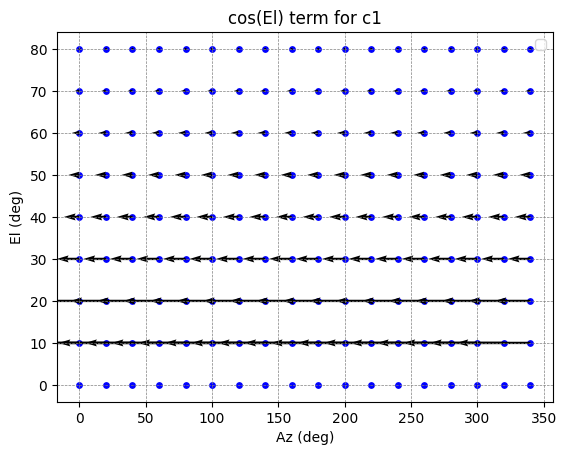

In [15]:
#plot cos(El) term for c1
plot_term(AZ, EL,
          a[1]*fa1,
          b[0]*0,
          "cos(El) term for c1")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


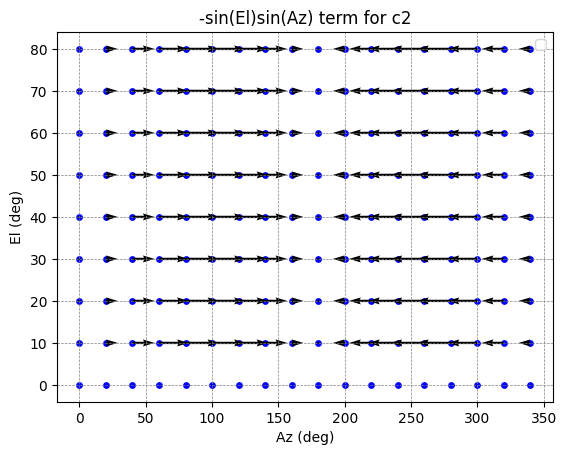

In [16]:
#plot -sin(El)sin(Az) term for c2
plot_term(AZ, EL,
          a[2]*fa2,
          b[0]*0,
          "-sin(El)sin(Az) term for c2")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


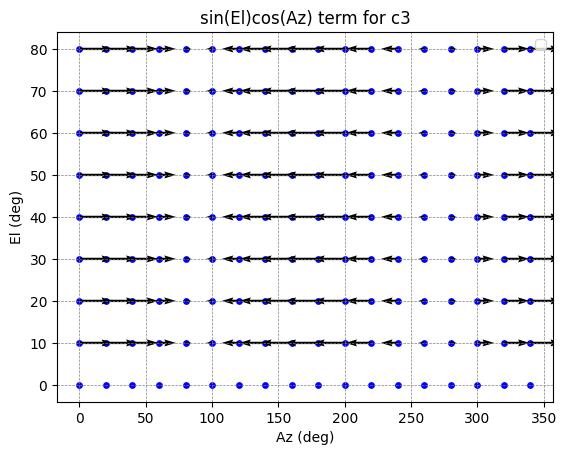

In [17]:
#plot sin(El)cos(Az) term for c3
plot_term(AZ, EL,
          a[3]*fa3,
          b[0]*0,
          "sin(El)cos(Az) term for c3")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


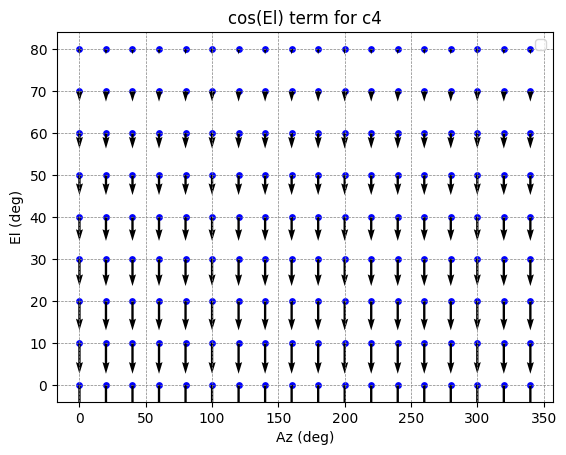

In [18]:
#plot cos term for c4
plot_term(AZ, EL,
          a[0]*0,
          b[1]*fb1,
          "cos(El) term for c4")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


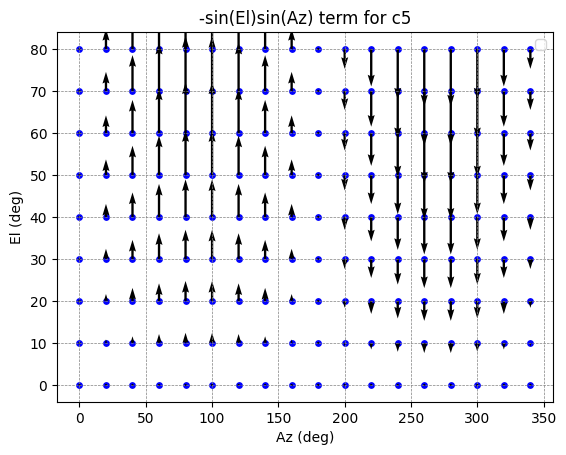

In [19]:
#plot -sin(El)sin(Az) term for c5
plot_term(AZ, EL,
          a[0]*0,
          b[2]*fb2,
          "-sin(El)sin(Az) term for c5")

/tmp/ipykernel_4424/1639776306.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


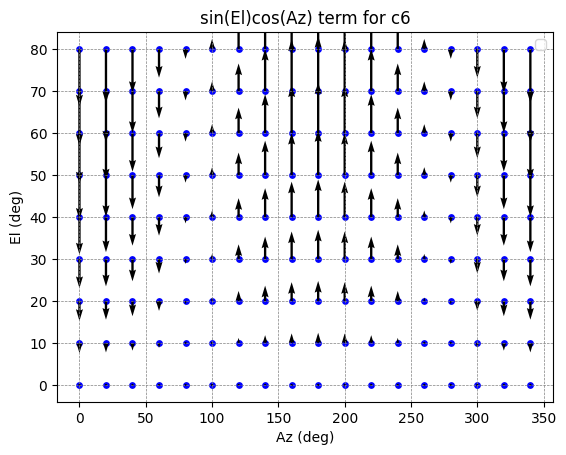

In [20]:
#plot sin(El)cos(Az) term for c6
plot_term(AZ, EL,
          a[0]*0,
          b[3]*fb3,
          "sin(El)cos(Az) term for c6")